In [1]:
import numpy as np
import pandas as pd
import your
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sys

from matplotlib import colors
from scipy.optimize import curve_fit, leastsq
import numpy.ma as ma
import matplotlib.ticker as ticker
from matplotlib.ticker import MaxNLocator

In [2]:
def downsample(data, freqf, timef):
    """ Downsamples a 2D array in time and or frequency"""
    
    nchan = data.shape[0]
    nsamps = data.shape[1]
    
    assert nchan % freqf == 0
    
    remainder = nsamps % timef
    if remainder > 0:
        print(f"Warning: removing the last {remainder} samples of the time-axis")
        print(f'Old shape (before downsampling): {data.shape}')
        data = data[:, :-remainder]
        print(f'Old shape (before downsampling): {data.shape}')
           
    data_down = data.reshape(-1, data.shape[-1]//timef, timef).mean(axis=2)
    data_down = data_down.reshape(-1, freqf, data_down.shape[-1]).mean(axis=1)
    return data_down

def dedisperse(data, dm, freqs, tsamp, dmconst=1.0 / (2.41 * 10.0**-4.0)):
    """
    Parameters
    ----------
    data : 2d numpy array
        data containing freq on the y-axis and time on the x-axis
    dm : float
        Dispersion measure in units of pc / cc.
    freqs : 1d numpy array
        Array containing the channel frequencies in units of MHz
    tsamp : float
        sampling time in units of seconds.
    dmconst: float
        dispersion constant in units of MHz^2 pc^-1 cm^3 s
        according to K Nimmo (https://ui.adsabs.harvard.edu/abs/2022NatAs...6..393N/abstract)
        this is also the value that is used in dspsr (digifil) and SFXC

    Returns
    -------
    ndata : 2d numpy
        dedispersed data

    """
    # set up freq info
    freqs = freqs.astype(np.float64)
    reffreq = np.max(freqs)
    
    # init empty array to store dedisp data in
    ndata = np.zeros(data.shape)
    
    # calculate time shifts and convert to bin shifts
    time_shift = dmconst * dm * (reffreq**-2.0 - freqs**-2.0)
    
    # round to nearest integer
    bin_shift = np.rint((time_shift / tsamp)).astype(np.int64)
    
    # checks
    assert len(bin_shift) == data.shape[0]
    assert ndata.shape == data.shape
    
    # dedisperse by rolling back the channels
    for i, bs in enumerate(bin_shift):
        ndata[i, :] = np.roll(data[i, :], bs)
        
    return ndata
    

def clone_cols(arr, n):
    """
    Parameters
    ----------
    arr : 2d-numpy array with shape k x m (rows x colums)
        input array that needs to be super-sampled.
    n : int
        supersampling factor.

    Returns
    -------
    narr : super-sampled 2d-numpy array with shape k x (m * n).
    
    Example
    -------
    arr = array([[0, 1, 2],
                 [3, 4, 5]])
    arr2 = clone_cols(arr, 3)
    >>> array([[0, 0, 0, 1, 1, 1, 2, 2, 2],
               [3, 3, 3, 4, 4, 4, 5, 5, 5]])
    
    """

    narr = np.zeros(shape=(arr.shape[0], arr.shape[1] * n), dtype=arr.dtype)
    
    for i in range(arr.shape[1]):
        narr[:, (i*n):((i+1)*n)] = arr[:, i][:, None]
    
    return narr


def super_dedisperse(data, dm, freqs, tsamp, nfac, dmconst=1.0 / (2.41 * 10.0**-4.0)):
    """
    Parameters
    ----------
    data : 2d numpy array
        data containing freq on the y-axis and time on the x-axis
    dm : float
        Dispersion measure in units of pc / cc.
    freqs : 1d numpy array
        Array containing the channel frequencies in units of MHz
    tsamp : float
        sampling time in units of seconds.
    nfac : int
        Integer to speficy by how much to 'increase' the sampling time by
    dmconst: float
        dispersion constant in units of MHz^2 pc^-1 cm^3 s
        according to K Nimmo (https://ui.adsabs.harvard.edu/abs/2022NatAs...6..393N/abstract)
        this is also the value that is used in dspsr (digifil) and SFXC

    Returns
    -------
    ndata : 2d numpy
        dedispersed data

    """
    # set up freq info
    freqs = freqs.astype(np.float64)
    reffreq = np.max(freqs)
    
    # duplicate columns of our data
    data_sup = clone_cols(data, nfac)
    
    # init empty array to store dedisp data in
    ndata = np.zeros(data_sup.shape)
    
    # calculate time shifts and convert to bin shifts
    time_shift = dmconst * dm * (reffreq**-2.0 - freqs**-2.0)
    # round to nearest integer
    sup_bin_shift = np.rint((nfac * time_shift / tsamp)).astype(np.int64)
        
    # checks
    assert len(sup_bin_shift) == data_sup.shape[0]
    
    assert ndata.shape == data_sup.shape
    
    # dedisperse by rolling back the channels
    for i, bs in enumerate(sup_bin_shift):
        ndata[i, :] = np.roll(data_sup[i, :], bs)
        
    # downsample the data back in time
    ndata = downsample(data=ndata, freqf=1, timef=nfac)
        
    return ndata


def super_dedisperse2(data_sup, dm, freqs, tsamp, nfac, dmconst=1.0 / (2.41 * 10.0**-4.0)):
    """
    Parameters
    ----------
    data_sup : 2d numpy array
        super-sampled data containing freq on the y-axis and time on the x-axis
    dm : float
        Dispersion measure in units of pc / cc.
    freqs : 1d numpy array
        Array containing the channel frequencies in units of MHz
    tsamp : float
        sampling time in units of seconds.
    nfac : int
        Integer to speficy by how much to 'increase' the sampling time by
    dmconst: float
        dispersion constant in units of MHz^2 pc^-1 cm^3 s
        according to K Nimmo (https://ui.adsabs.harvard.edu/abs/2022NatAs...6..393N/abstract)
        this is also the value that is used in dspsr (digifil) and SFXC

    Returns
    -------
    ndata : 2d numpy
        dedispersed data
        
    Extra
    -----
    Should be used if the same dynamic spectrum is going to be dedispersed over a range
    of trial DMs. If only one DM is going to be used see the function super_dedisperse()

    """
    # set up freq info
    freqs = freqs.astype(np.float64)
    reffreq = np.max(freqs)
    
    # init empty array to store dedisp data in
    ndata = np.zeros(data_sup.shape)
    
    # calculate time shifts and convert to bin shifts
    time_shift = dmconst * dm * (reffreq**-2.0 - freqs**-2.0)
    # round to nearest integer
    sup_bin_shift = np.rint((nfac * time_shift / tsamp)).astype(np.int64)
        
    # checks
    assert len(sup_bin_shift) == data_sup.shape[0]
    
    assert ndata.shape == data_sup.shape
    
    # dedisperse by rolling back the channels
    for i, bs in enumerate(sup_bin_shift):
        ndata[i, :] = np.roll(data_sup[i, :], bs)
        
    # downsample the data back in time
    ndata = downsample(data=ndata, freqf=1, timef=nfac)
        
    return ndata

In [3]:
def normalize(ds,op):
    ds=ds.copy().astype(float)
    op=op.copy().astype(float)
    nds=np.zeros_like(ds)

    for chan in range(ds.shape[0]):
        channel=ds[chan,:]
        offburstchannel=op[chan,:]

        chan_mean=np.median(offburstchannel)
        chan_std=np.std(offburstchannel)
        if chan_std != 0:
            newchannel=(channel-chan_mean)/chan_std

        nds[chan,:]=newchannel

    return nds


In [39]:
def waterfaller_maker(burst):
    """
    ax1 ax3 ax5
    ax2 ax4 ax6

    the burst has to be a filpath and bursts are processed with YOUR and dedispersing code written by Snelders
    """
    
    #Define the figure
    fig5 = plt.figure(figsize=(20*(1/3),10))
    
    #Width 0.1 is for the hidden axes
    widths = [1]
    heights = [1, 2.5]
    spec5 = fig5.add_gridspec(ncols=1, nrows=2, width_ratios=widths, height_ratios=heights,\
                              wspace=0.25, hspace=0.0)

    ###################################
    ## Onsala ## 
    burst = your.Your(burst_list[0])
    
    tsamp = burst.your_header.tsamp #in seconds
    nbins = burst.your_header.nspectra       
    fsamp = burst.your_header.foff * -1 #in MHz
    
    tmin = 0.0
    tmax = nbins * burst.tsamp # seconds
    fmin = np.min(burst.chan_freqs) - np.abs(burst.foff) / 2.0
    fmax = np.max(burst.chan_freqs) + np.abs(burst.foff) / 2.0
    extent_b = [tmin, tmax, fmin, fmax]
    
    offset = 2.628
    extent_b[0] = (tmin - offset) * 1000
    extent_b[1] = (tmax - offset) * 1000
    print(extent_b)
    #time increasing, freq decreasing
    print("loading in the data")
    d = burst.get_data(0,nbins,npoln=1)
    
    freqs = burst.chan_freqs # in Mhz
    
    print("de-dispersing")
    dm_dedisp = 527.8
    stokes_i = dedisperse(d.T,dm_dedisp,freqs,tsamp)
    
    norm_v1=10 
    norm_v2=800
    stokes_i = normalize(stokes_i,stokes_i[:,norm_v1:norm_v2])
    downsamp_t = 2
    downsamp_f = 64
    tsamp_down = tsamp * downsamp_t
    freq_down = fsamp * downsamp_f

    stokes_i = downsample(stokes_i, freqf=downsamp_f, timef=downsamp_t)

    new_quantiles = np.percentile(stokes_i, (1, 99.2))
    
    #Create x grid to plot the step function. 
    x_grid = np.linspace(extent_b[0], extent_b[1], endpoint=False, num=stokes_i.shape[1])
    
    #make profile
    prof = np.mean(stokes_i,axis=0)
    offprof = prof[norm_v1:norm_v2]
    offprof_std = np.std(offprof)
    offprof_mean = np.mean(offprof)   
    stokes_i_normprof = (prof - offprof_mean) / offprof_std
    #stokes_i_normprof = stokes_i_normprof[10000:10500] #hardcoded 60ms
    
    ax2 = fig5.add_subplot(spec5[1, 0])
    ax2.imshow(stokes_i, aspect='auto', interpolation='None',\
          extent=extent_b, vmin=new_quantiles[0], vmax=new_quantiles[1])
    ax2.set_xlim(-35,35)
    ax2.set_ylim(300,356)
    ax2.set_ylabel('Frequency (MHz)',size=25)
    ax2.set_xlabel('Time (ms)',size=25)
    ax2.yaxis.set_major_locator(ticker.LinearLocator(5))
    ax2.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    
    ax1 = fig5.add_subplot(spec5[0, 0], sharex=ax2)
    ax1.set_ylabel('S/N',size=25)
    ax1.plot(x_grid, stokes_i_normprof, drawstyle='steps-post', color='black')

    ax1.text(0.04, 0.93, "Westerbork" + "\n" + "RT-1", transform=ax1.transAxes, fontsize=25, va='top', ha='left')
    #ax1.text(-28,12, f"DM = 219.37" + r" pc cm$^{-3}$", fontsize=18)
    
    #Ticks on the SN-
    maxSN = np.ceil(np.max(stokes_i_normprof))
    yticks_sn=np.array([0,maxSN])
    ax1.set_yticks(yticks_sn)
    #ax1.yaxis.set_minor_locator(ticker.LinearLocator(3))
    ax1.set_ylim(-7,maxSN+5)

    ax1.text(0.65, 0.93, fr"{(tsamp_down*1e6):.2f} $\mu$s", transform=ax1.transAxes, fontsize=18, va='top', ha='left')
    ax1.text(0.65, 0.78, fr"{(freq_down*1e3):.2f} kHz", transform=ax1.transAxes, fontsize=18, va='top', ha='left')
    
    ###################################
    ###################################    
    ###################################
    
    #Setting labels and ticks 
    for ax in [ax1,ax2]:
        
        ax.tick_params(labelsize=22) 
        
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2)

            ax.tick_params(axis='y', which='major', direction='out', length=10, width=2)
            ax.tick_params(axis='y', which='minor', direction='out', length=5, width=2)
            ax.tick_params(axis='x', which='major', direction='out', length=10, width=2)
            ax.tick_params(axis='x', which='minor', direction='out', length=5, width=2)
    
    for ax in [ax1]:
        
        ax.tick_params(labelbottom=False)
        ax.tick_params(axis='x', which='major', direction='in', length=10, width=2)
        ax.tick_params(axis='x', which='minor', direction='in', length=5, width=2)
        
    # ax2.tick_params(labelleft=False)
    # ax5.tick_params(labelleft=False)
    
    plot_name = "atel_figure1"
    fig5.savefig(plot_name + ".pdf", dpi=600, bbox_inches='tight')
    
    fig5.savefig(plot_name + ".png", facecolor='white', \
            transparent=False, format = 'png',bbox_inches='tight', dpi=600)
    return

[-2628.0, 9168.607999999998, 300.0, 364.0]
loading in the data
de-dispersing
Old shape (before downsampling): (8192, 92161)
Old shape (before downsampling): (8192, 92160)


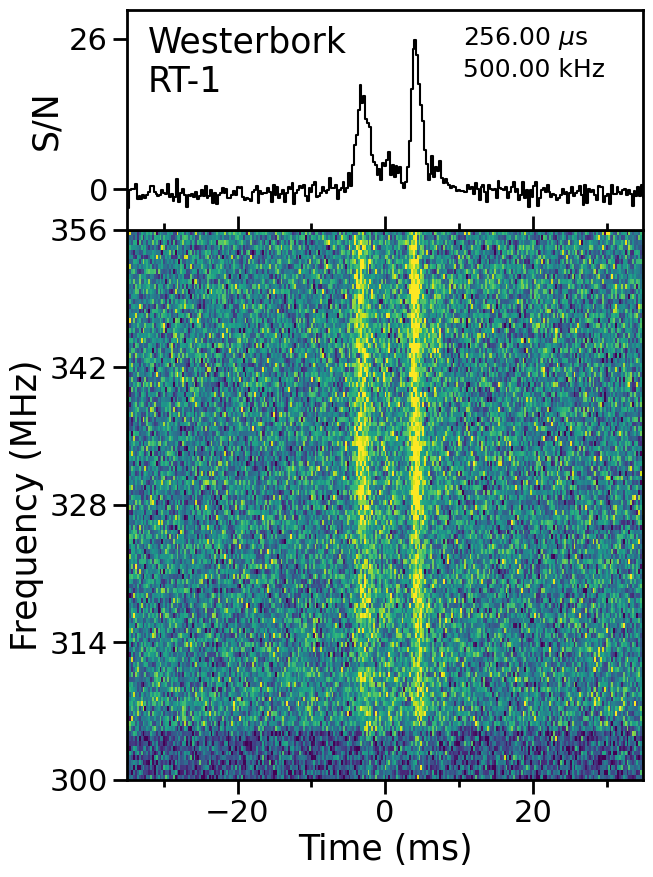

In [40]:
burst_list = ['/data1/omar/p47030/p47030_wb_no0021_IFall_vdif_pol2.fil']

waterfaller_maker(burst=burst_list)